In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()

,age,study_hours,attendance,previous_score,assignments,internal_marks,sleep_hours,internet_usage,final_score,gender_Male,extra_activities_Yes,parent_education_School,family_income_Low,family_income_Medium
0,22,6.3,96,83,85,73,5.5,2.2,39.8,True,False,False,True,False
1,22,4.4,73,59,89,39,7.3,6.0,30.2,False,False,False,False,True
2,22,9.7,71,75,83,99,8.7,5.7,42.1,True,False,True,False,True
3,22,8.6,54,48,98,47,8.4,7.8,34.2,True,False,False,False,False
4,21,8.5,82,77,82,87,7.8,6.3,41.2,True,True,False,True,False


In [4]:
#Define Features & Target
X = df.drop('final_score', axis=1)
y = df['final_score']

In [5]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#Model Training (Multiple Models)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [7]:
#Model Evaluation
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.03,0.03,1.0000
1,Decision Tree,1.91,2.55,0.7561
2,Random Forest,0.95,1.25,0.9416


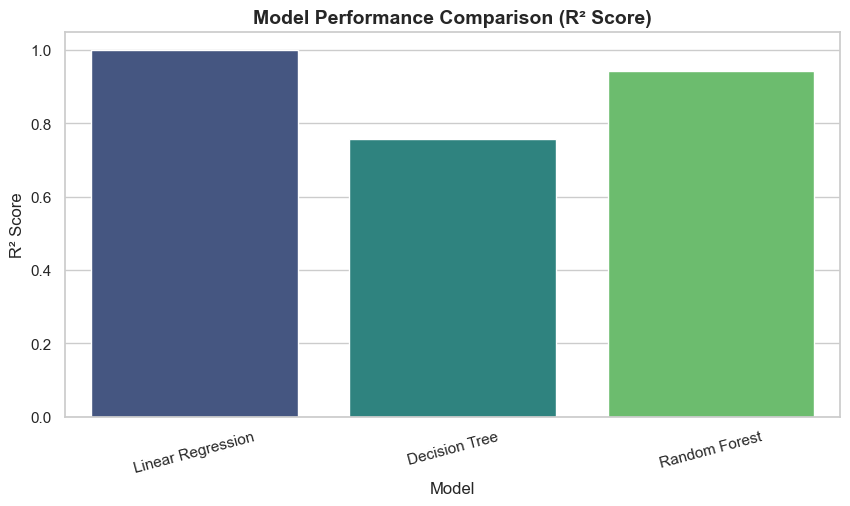

In [8]:
#Model Comparison Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    palette="viridis"
)

plt.title("Model Performance Comparison (R² Score)", fontsize=14, fontweight='bold')
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

In [9]:
#Best Model Selection
best_model_name = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Linear Regression


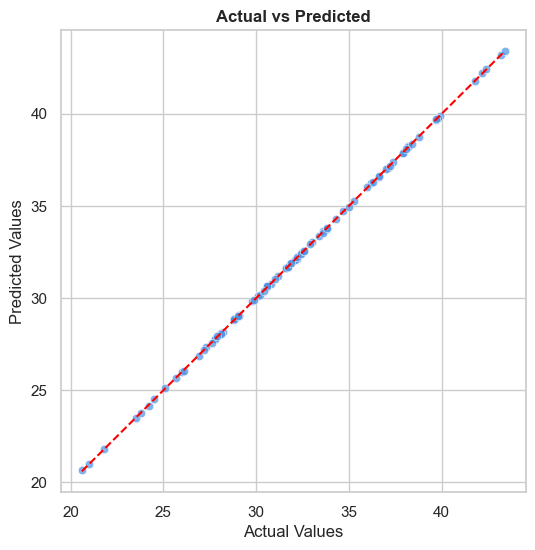

In [10]:
#Actual vs Predicted Plot (Best Model)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))

sns.scatterplot(x=y_test, y=y_pred, color="#4A90E2", alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.title("Actual vs Predicted", fontweight='bold')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.show()

In [12]:
#Save Model
import pickle

with open("../models/student_model.pkl", "wb") as f:
    pickle.dump(best_model, f)